In [2]:
pip install tensorflow pandas matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.9/351.2 MB 16.1 MB/s eta 0:00:22
    --------------------------------------- 5.2/351.2 MB 13.0 MB/s eta 0:00:27
    --------------------------------------- 7.3/351.2 MB 12.0 MB/s eta 0:00:29
   - -------------------------------------- 10.2/351.2 MB 12.5 MB/s eta 0:00:28
   - -------------------------------------- 14.2/351.2 MB 14.0 MB/s eta 0:00:25
   -- ------------------------------------- 18.4/351.2 MB 14.9 MB/s eta 0:00:23
   -- ------------------------------------- 22.8/351.2 MB 15.8 MB/s eta 0:00:21
   -- ------------------------------------- 25.2/351.2 MB 15.4 MB/s eta 0:00:22
   --- ------------------------------------ 27.0/351.2 MB 14.6 MB/s eta 0:00:23
   --- ------------------------------------ 30.9/351.2 MB 15.1 MB/s eta 0:00:22
   --- ------------------------------------ 33.3/351.2 MB 14.6 MB/s eta 0:00:22
   ---- ----------------------------------- 35.4/351

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [3]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
from sklearn.datasets import load_iris

# Split Dataset
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Performance Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [4]:
# Load Iris Dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Classes:")
print(iris.target_names)

print("\nShape of Features:", X.shape)
print("Shape of Labels:", y.shape)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

Shape of Features: (150, 4)
Shape of Labels: (150,)


In [5]:
# Convert to DataFrame

df = pd.DataFrame(X, columns=iris.feature_names)

# Add Target Column
df["Species"] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [6]:
# Basic Information

print("Dataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Statistical Summary
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%      

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24432\2330161221.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


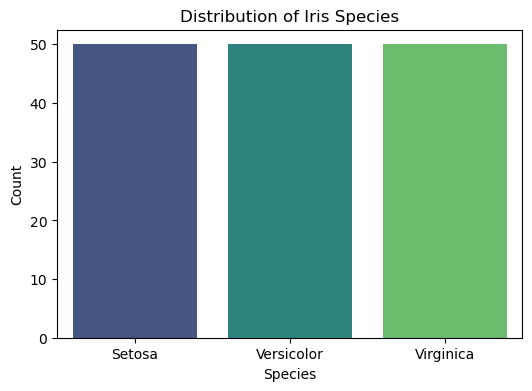

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Species",
    data=df,
    palette="viridis"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.xticks(
    [0,1,2],
    ["Setosa","Versicolor","Virginica"]
)

plt.show()

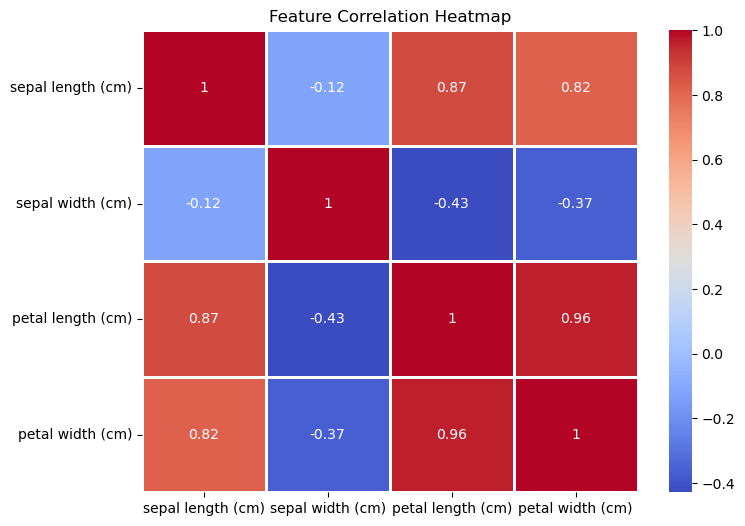

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("Species", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Feature Correlation Heatmap")

plt.show()

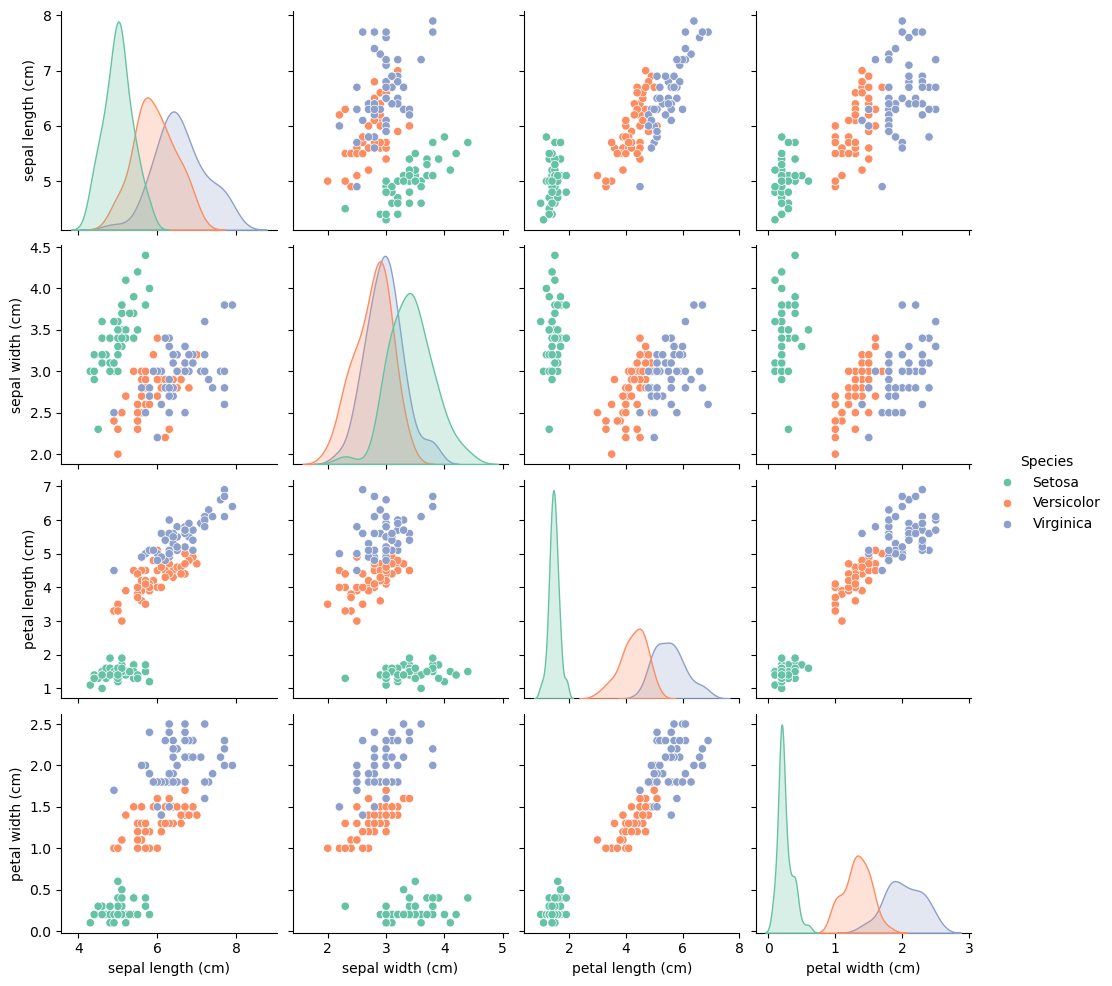

In [9]:
df_plot = df.copy()

df_plot["Species"] = df_plot["Species"].map({
    0:"Setosa",
    1:"Versicolor",
    2:"Virginica"
})

sns.pairplot(
    df_plot,
    hue="Species",
    palette="Set2"
)

plt.show()

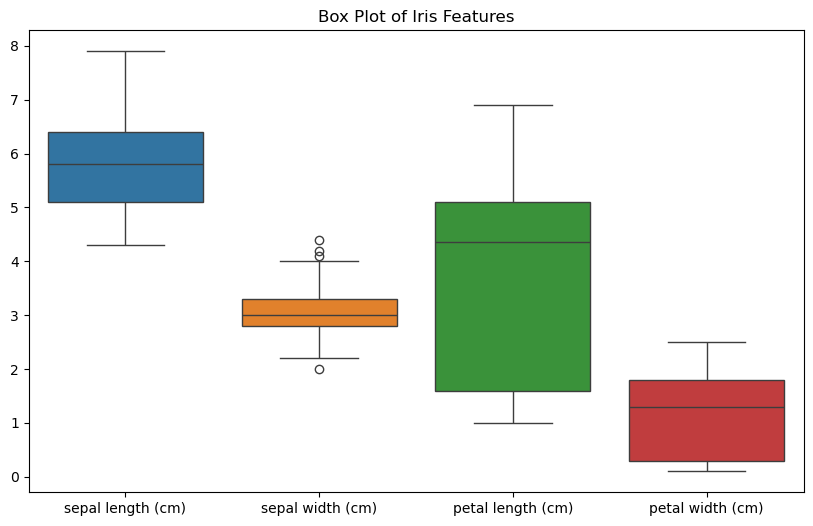

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df.iloc[:,:4])

plt.title("Box Plot of Iris Features")

plt.show()

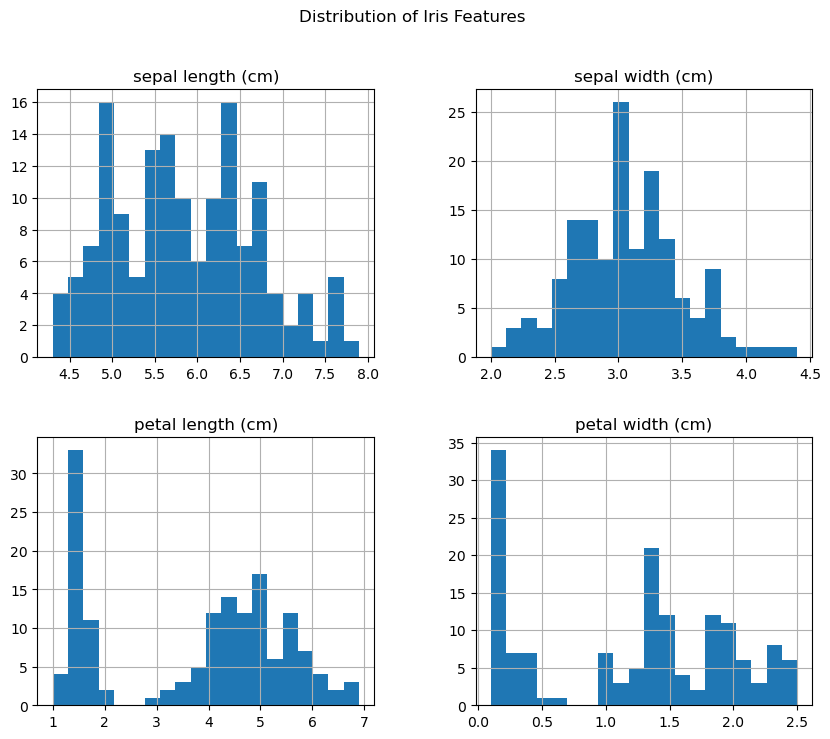

In [11]:
df.iloc[:, :4].hist(
    figsize=(10,8),
    bins=20
)

plt.suptitle("Distribution of Iris Features")

plt.show()

In [12]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (120, 4)
Testing Data Shape  : (30, 4)


In [13]:
# Standardize the Features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("First 5 rows of Scaled Training Data:")
print(X_train[:5])

First 5 rows of Scaled Training Data:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


In [14]:
# Create MLP Model

model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(4,)
))

# Hidden Layer 2
model.add(Dense(
    units=8,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=3,
    activation='softmax'
))

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2604 - loss: 1.0616 - val_accuracy: 0.5000 - val_loss: 0.9644
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 0.9666 - val_accuracy: 0.5000 - val_loss: 0.8834
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5521 - loss: 0.8917 - val_accuracy: 0.5417 - val_loss: 0.8163
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6042 - loss: 0.8264 - val_accuracy: 0.7500 - val_loss: 0.7628
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6667 - loss: 0.7724 - val_accuracy: 0.7917 - val_loss: 0.7200
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7083 - loss: 0.7276 - val_accuracy: 0.8750 - val_loss: 0.6844
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7188 - loss: 0.6906 - val_accuracy: 0.7917 - val_loss: 0.6541
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7708 - loss: 0.6551 - val_accuracy: 0.7917 - 

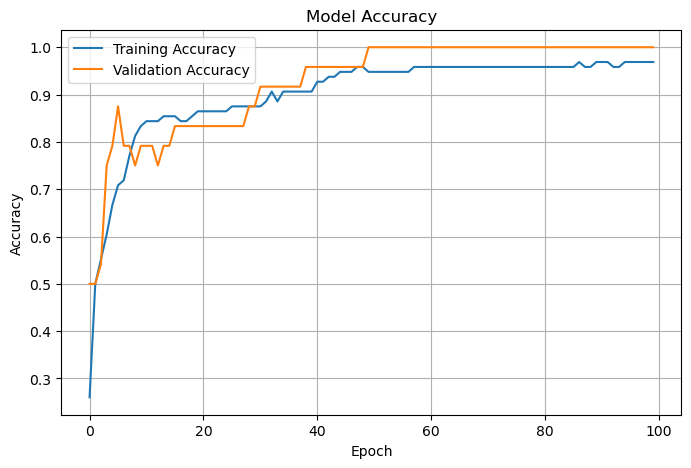

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

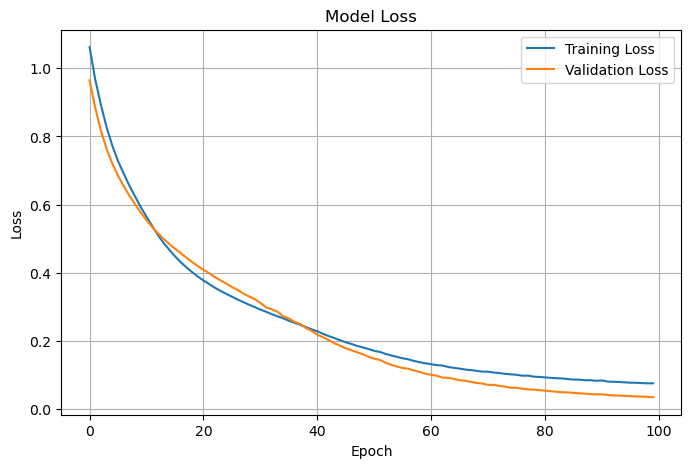

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [20]:
# Predict probabilities

y_pred = model.predict(X_test)

# Convert probabilities to class labels

y_pred_classes = np.argmax(y_pred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [21]:
accuracy = accuracy_score(y_test, y_pred_classes)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9333333333333333


In [22]:
cm = confusion_matrix(y_test, y_pred_classes)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


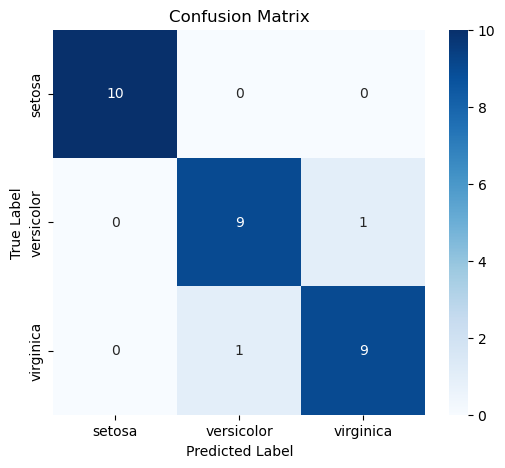

In [23]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [24]:
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [25]:
sample = [[5.1, 3.5, 1.4, 0.2]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

print("Predicted Flower:", iris.target_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Flower: setosa
